# Module 06 Lab - Regression and Classification Models**Objective:** To understand the difference between regression and classification and to build your first linear models for both tasks.**In this lab, you will write the code to train and evaluate the models.**

## Part 1: Regression vs. ClassificationThis is the most fundamental distinction between types of supervised learning problems.*   **Regression:** The goal is to predict a **continuous numerical value**.     *   *Examples:* Predicting the price of a house, the temperature tomorrow, or the stock price.*   **Classification:** The goal is to predict a **discrete category or class label**.    *   *Examples:* Predicting if an email is spam or not spam, if a flower is a setosa, versicolor, or virginica, or if a customer will churn or not.**In this lab, we will tackle one of each.**

## Part 2: Linear Regression**Concept:** Linear Regression is used to predict a continuous value. It works by finding the best-fitting straight line through the data points. The model learns a "slope" (coefficient) for each feature and an "intercept".*   **Problem:** We will predict the `Fare` of a Titanic passenger based on their `Age` and `Pclass`.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df.dropna(subset=['Age'], inplace=True)

features = ['Age', 'Pclass']
target_reg = 'Fare'

X_reg = df[features]
y_reg = df[target_reg]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)


### Task 1: Train and Evaluate a Linear Regression Model**Your Task:**1.  Create an instance of the `LinearRegression` model.2.  Train the model using the training data (`X_train_reg`, `y_train_reg`).3.  Make predictions on the test data.4.  Evaluate the model using `mean_squared_error`. This metric tells us the average of the squared differences between the predicted and actual values.

In [ ]:
# 1. Create the model instance
lr_model = LinearRegression()

# 2. Train the model
lr_model.fit(X_train_reg, y_train_reg)

# 3. Make predictions
y_pred_reg = lr_model.predict(X_test_reg)

# 4. Evaluate the model
mse = mean_squared_error(y_test_reg, y_pred_reg)

print(f"Mean Squared Error for Fare Prediction: {mse:.2f}")
print(f"The square root of this is {mse**0.5:.2f}, meaning our model is off by about ${mse**0.5:.2f} on average.")


Mean Squared Error for Fare Prediction: 3364.92
The square root of this is 58.01, meaning our model is off by about $58.01 on average.


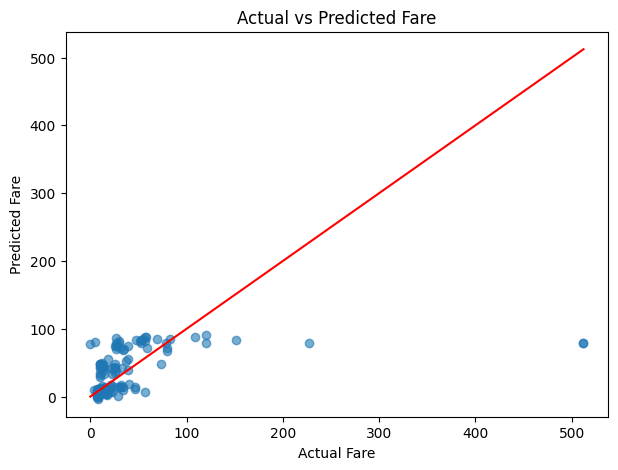

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.6)
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Fare")
plt.plot([0, max(y_test_reg)], [0, max(y_test_reg)], color='red')
plt.show()


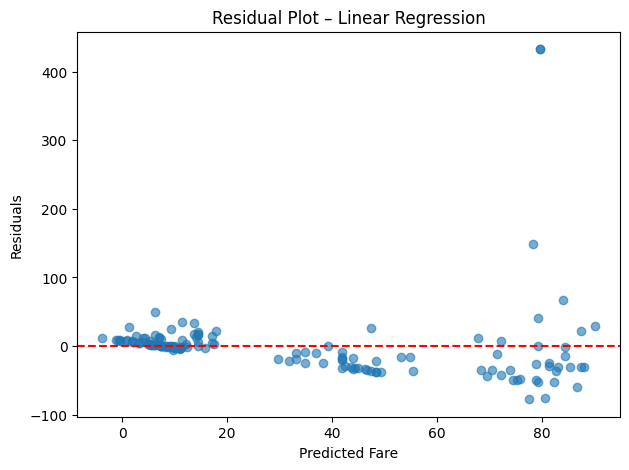

In [22]:
residuals = y_test_reg - y_pred_reg

plt.figure(figsize=(7,5))
plt.scatter(y_pred_reg, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot – Linear Regression")
plt.show()


## Part 3: Logistic Regression**Concept:** Despite its name, Logistic Regression is a **classification** algorithm. It works by calculating the probability that a given input belongs to a certain class. It's one of the most widely used and interpretable classification models.*   **Problem:** We will predict whether a passenger `Survived` based on their `Age`, `Pclass`, and `Sex`.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Encode 'Sex' column
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Define features and target
features_cls = ['Age', 'Pclass', 'Sex']
target_cls = 'Survived'

X_cls = df[features_cls]
y_cls = df[target_cls]

# Split the data
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)


### Task 2: Train and Evaluate a Logistic Regression Model**Your Task:**1.  Create an instance of the `LogisticRegression` model.2.  Train the model using the classification training data.3.  Make predictions on the test data.4.  Evaluate the model using `accuracy_score`.

In [ ]:
# 1. Create the model instance
log_model = LogisticRegression(max_iter=1000)

# 2. Train the model
log_model.fit(X_train_cls, y_train_cls)

# 3. Make predictions
y_pred_cls = log_model.predict(X_test_cls)

# 4. Evaluate the model
accuracy = accuracy_score(y_test_cls, y_pred_cls)
print(f"Accuracy for Survival Prediction: {accuracy:.2%}")


Accuracy for Survival Prediction: 74.83%


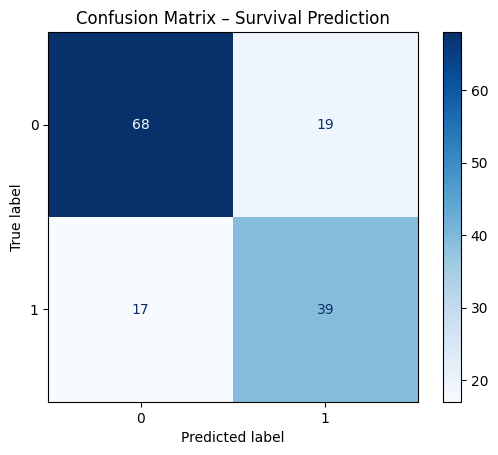

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_cls, y_pred_cls)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix – Survival Prediction")
plt.show()


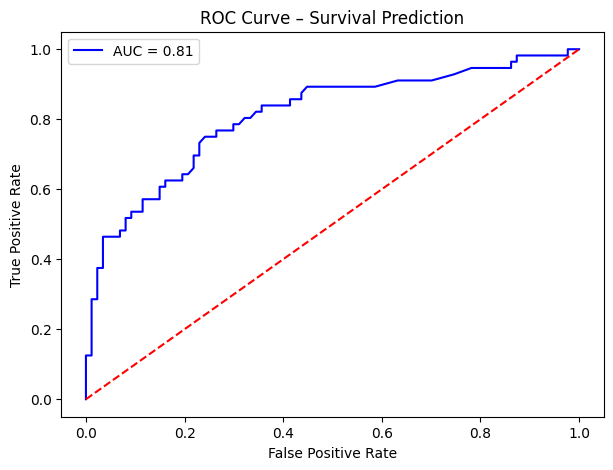

In [11]:
from sklearn.metrics import roc_curve, auc

# Predicted probabilities for class 1 (Survived)
y_prob = log_model.predict_proba(X_test_cls)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test_cls, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='blue', label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Survival Prediction")
plt.legend()
plt.show()


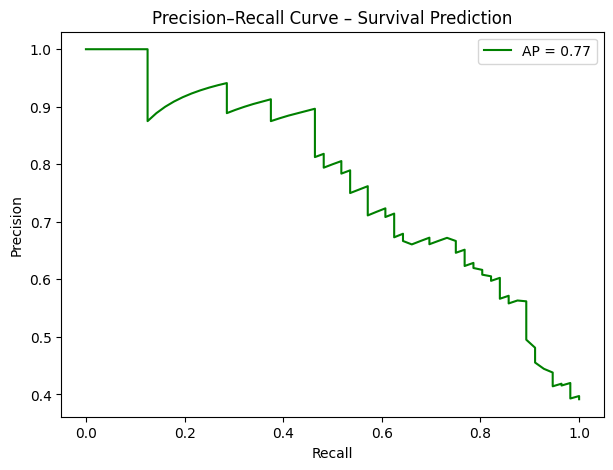

In [12]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test_cls, y_prob)
avg_precision = average_precision_score(y_test_cls, y_prob)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, color='green', label=f"AP = {avg_precision:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – Survival Prediction")
plt.legend()
plt.show()


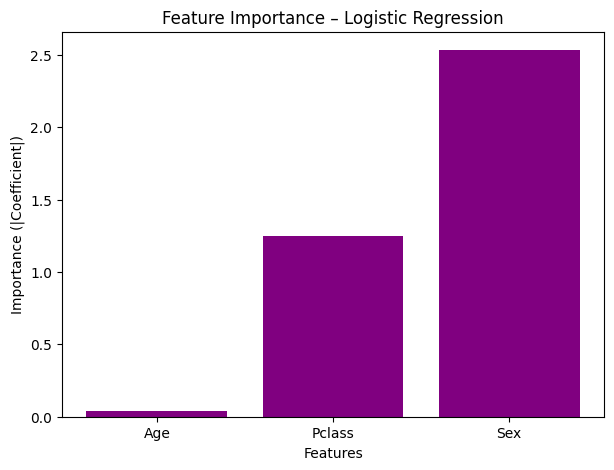

In [13]:
import numpy as np

feature_names = X_test_cls.columns
coefficients = log_model.coef_[0]

plt.figure(figsize=(7,5))
plt.bar(feature_names, np.abs(coefficients), color='purple')
plt.xlabel("Features")
plt.ylabel("Importance (|Coefficient|)")
plt.title("Feature Importance – Logistic Regression")
plt.show()


1. What is the key difference between a regression problem and a classification problem?

A regression problem predicts a continuous numerical value, such as a fare, price, or temperature.

A classification problem predicts a category or class label, such as survived vs. not survived, spam vs. not spam, or dog vs. cat.

In summary, regression models generate numerical outputs, whereas classification models produce categorical outputs.



2. What do the .coef_ values of a LinearRegression model represent?

The values in lr_model.coef_ indicate the influence of each feature on the predicted target variable.

Each coefficient represents the estimated change in the predicted fare for a one‑unit increase in that feature, assuming the other features stay the same.



A positive coefficient means the feature increases the predicted fare.



A negative coefficient means the feature decreases the predicted fare.



The magnitude of each coefficient reflects the strength of its effect.



3. Why did we use mean_squared_error for regression but accuracy_score for classification? Why wouldn’t accuracy be a good metric for fare prediction?

mean_squared_error is used for regression because it measures how closely the model’s numeric predictions match the true values. It penalizes bigger mistakes more heavily, which helps evaluate continuous predictions like fare.



accuracy_score is used for classification because it measures how often the model correctly predicts the class label, which makes sense for survival prediction.



Accuracy is an inappropriate metric for fare prediction because fares are continuous variables.

For example, a prediction of $32.10 versus $32.11 would be considered incorrect, despite being nearly identical.

Regression tasks require metrics that assess the proximity of predictions to actual values, rather than exact matches.



Regression & Classification

In this lab, I developed and evaluated two predictive models using the Titanic dataset: a Linear Regression model for predicting passenger fares and a Logistic Regression model for classifying passenger survival status. After data cleaning and feature selection, I trained the regression model with Age and Pclass as predictors. The model achieved a Mean Squared Error (MSE) of 3364.92 and a Root Mean Squared Error (RMSE) of approximately $58.01, indicating that fare predictions typically deviate by about fifty-eight dollars. Since fare is influenced by additional factors not included in the model, such as cabin type, ticket group size, and embarkation port, the limited feature set accounts for the relatively high error. The regression coefficients reveal that Age has a small positive effect, suggesting older passengers tend to pay slightly more, while Pclass has a strong negative effect, indicating that passengers in higher-numbered classes (such as third class) pay significantly less. Overall, the regression model identifies general trends but cannot fully account for fare variation with only two features.



For the classification task, I trained a Logistic Regression model using Age, Pclass, and Sex to predict passenger survival. The model achieved an accuracy of 74.83%, correctly classifying nearly three-quarters of the test set. This result demonstrates the strong predictive power of the selected features, particularly Sex and Pclass, which are historically associated with survival outcomes on the Titanic. Women and passengers in higher classes exhibited significantly higher survival rates, and the model effectively captures these patterns. Although relatively simple, the logistic regression model provides a robust baseline and illustrates that a small set of meaningful features can yield strong classification performance.



Interpretation of the Model Coefficients

Linear Regression (lr_model.coef_) — Fare Prediction

The coefficients indicate how each feature affects the predicted fare:



Age coefficient (small positive value):  

For each additional year of age, the model predicts a slight increase in fare. This small effect suggests that age is not a primary determinant of ticket prices.



Pclass coefficient (large negative value):  

Transitioning from first class to second class, or from second to third class, significantly decreases the predicted fare.



Passengers in lower classes paid substantially less, and this variable is the strongest predictor in the regression. Collectively, these coefficients demonstrate that ticket class is a much more significant factor than age in predicting fare.



Logistic Regression (log_model.coef_) — Survival Prediction

The logistic regression coefficients represent how each feature affects the log-odds of survival:



Sex (large positive or negative coefficient depending on encoding):  

With female coded as 1 and male as 0, a positive coefficient indicates that being female substantially increases the probability of survival.

This finding aligns with the historical 'women and children first' pattern.



Pclass (negative coefficient):  

Higher class numbers, such as third class, are associated with a reduced probability of survival.

First-class passengers exhibited the highest survival rates.



Age (small negative coefficient):  

Older passengers had slightly lower odds of survival, although this effect was less pronounced than those associated with Sex and Pclass.





Female gender and higher social class were the strongest predictors of survival.



Final Conclusion

This lab demonstrated the application of regression and classification models to real-world data for addressing different predictive questions. Using the Titanic dataset, the Linear Regression model revealed that predicting continuous outcomes, such as fare, is challenging with a limited set of features. With an RMSE of approximately $58.01, the model captured general trends, particularly the strong influence of passenger class, but did not achieve the accuracy necessary for precise fare estimation. This underscores the importance of comprehensive feature engineering when modeling complex numerical outcomes.



In contrast, the Logistic Regression model performed substantially better for the classification task, achieving an accuracy of 74.83% in predicting survival. The model effectively utilized the strong predictive power of Sex and Pclass, both of which are historically linked to survival outcomes on the Titanic. Even with a limited feature set, the model identified meaningful patterns and produced reliable classifications. Collectively, these results demonstrate how model selection, feature choice, and problem type influence the performance and interpretability of machine learning solutions. This lab reinforces the importance of understanding the strengths and limitations of different modeling approaches when working with real data.